├── KHỐI 1: QUẢN LÝ DỮ LIỆU (Bài 1, 2, 3, 4)

│   └── Tải dữ liệu -> Kiểm tra cấu trúc -> Hiển thị ảnh -> Chia tập Train/Val

│

├── KHỐI 2: XÂY DỰNG PIPELINE PYTORCH (Bài 5, 6, 12)

│   └── Khai báo Transform -> Định nghĩa Dataset Class -> Tạo DataLoader (Thử nghiệm các Batch size khác nhau)

│

├── KHỐI 3: ĐỊNH NGHĨA MÔ HÌNH VÀ LOSS (Bài 7, 8, 15)

│   └── Khai báo SimpleUNet (hoặc DeepLabV3) -> Định nghĩa BCE Loss / Dice Loss

│

├── KHỐI 4: HUẤN LUYỆN VÀ TINH CHỈNH (Bài 7, 11)

│   └── Chạy vòng lặp huấn luyện (Thử nghiệm thay đổi các Learning Rate khác nhau)

│

└── KHỐI 5: ĐÁNH GIÁ VÀ PHÂN TÍCH (Bài 9, 10, 13, 14)

    └── Tính IoU tập Val -> Hiển thị kết quả dự đoán -> Lọc các ảnh lỗi nặng nhất -> Đề xuất hướng cải tiến
    

In [1]:
import os
import glob

DATASET_DIR = "/kaggle/input/datasets/ipythonx/carvana-image-masking-png" 

image_paths = sorted(glob.glob(os.path.join(DATASET_DIR, "train_images/*"))) 
mask_paths = sorted(glob.glob(os.path.join(DATASET_DIR, "train_masks/*")))

print(f"Tổng số lượng ảnh gốc: {len(image_paths)}")
print(f"Tổng số lượng ảnh masks: {len(mask_paths)}")

if len(image_paths) == len(mask_paths):
    print("ảnh và mask khớp nhau.")
else:
    print("ảnh và mask lệch")

Tổng số lượng ảnh gốc: 5088
Tổng số lượng ảnh masks: 5088
ảnh và mask khớp nhau.


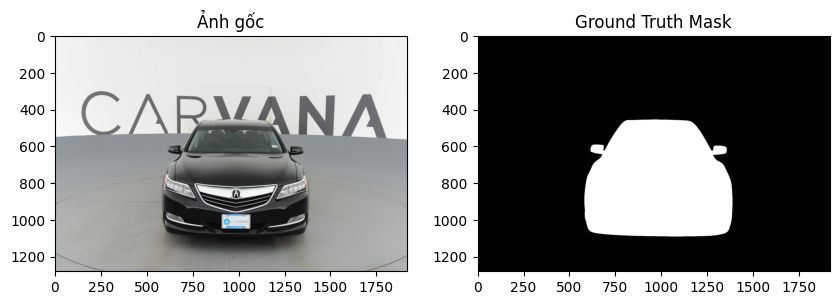

In [2]:
import cv2
import matplotlib.pyplot as plt

sample_img = cv2.imread(image_paths[0])
sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB) 
sample_mask = cv2.imread(mask_paths[0], 0) 

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(sample_img) 
plt.title("Ảnh gốc")

plt.subplot(1, 2, 2)
plt.imshow(sample_mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.show()

In [3]:
from sklearn.model_selection import train_test_split 

train_images, val_images, train_masks, val_masks = train_test_split(
    image_paths, 
    mask_paths, 
    test_size=0.2, 
    random_state=42
) 

print(f"Số lượng ảnh tập Train: {len(train_images)}")
print(f"Số lượng ảnh tập Validation: {len(val_images)}")

Số lượng ảnh tập Train: 4070
Số lượng ảnh tập Validation: 1018


# Bài 5: Tạo Dataset Class

In [4]:
import torch
import cv2
from torch.utils.data import Dataset 
from torchvision import transforms 

image_transform = transforms.Compose([
    transforms.ToPILImage(), 
    transforms.Resize((256, 256)),
    transforms.ToTensor() 
]) 

mask_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256)), 
    transforms.ToTensor() 
]) 

class SegmentationDataset(Dataset): 
    def __init__(self, image_paths, mask_paths): 
        self.image_paths = image_paths 
        self.mask_paths = mask_paths 
        
    def __len__(self): 
        return len(self.image_paths) 
        
    def __getitem__(self, idx): 
        
        image = cv2.imread(self.image_paths[idx]) 
        mask = cv2.imread(self.mask_paths[idx], 0) 
        
        image = image_transform(image) 
        mask = mask_transform(mask) 
        
        return image, mask 

# Bài 6: Tạo DataLoader

In [5]:
from torch.utils.data import DataLoader 

train_dataset = SegmentationDataset(train_images, train_masks) 
val_dataset = SegmentationDataset(val_images, val_masks) 

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True 
) 

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False
) 

# Bài 7

In [6]:
import torch.nn as nn 

class SimpleUNet(nn.Module): 
    def __init__(self):
        super(SimpleUNet, self).__init__() 
        
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(), 
            nn.MaxPool2d(2), 
            nn.Conv2d(16, 32, 3, padding=1), 
            nn.ReLU(), 
            nn.MaxPool2d(2) 
        ) 
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 2, stride=2), 
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 2, stride=2),
            nn.Sigmoid() 
        )
        
    def forward(self, x): 
        x = self.encoder(x) 
        x = self.decoder(x) 
        return x 

Vòng lặp huấn luyện sử dụng hàm Loss BCE ban đầu

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleUNet().to(device) 
criterion_bce = nn.BCELoss() 

optimizer = torch.optim.Adam(model.parameters(), lr=0.001) 

for epoch in range(10):
    model.train()
    epoch_loss = 0.0
    for images, masks in train_loader: 
        images = images.to(device) 
        masks = masks.to(device) 
        
        preds = model(images) 
        loss = criterion_bce(preds, masks) 
        
        optimizer.zero_grad()
        loss.backward() 
        optimizer.step() 
        
        epoch_loss += loss.item()
        
    print(f"Epoch {epoch+1}/10 - Loss (BCE): {epoch_loss/len(train_loader):.4f}")

Epoch 1/10 - Loss (BCE): 0.0440
Epoch 2/10 - Loss (BCE): 0.0065
Epoch 3/10 - Loss (BCE): 0.0064
Epoch 4/10 - Loss (BCE): 0.0064
Epoch 5/10 - Loss (BCE): 0.0064
Epoch 6/10 - Loss (BCE): 0.0064
Epoch 7/10 - Loss (BCE): 0.0064
Epoch 8/10 - Loss (BCE): 0.0063
Epoch 9/10 - Loss (BCE): 0.0063
Epoch 10/10 - Loss (BCE): 0.0063


# Bài tập 8: Thử nghiệm Dice Loss

In [8]:
def dice_loss(pred, target): 
    smooth = 1.0 
    intersection = (pred * target).sum() 
    dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth) 
    return 1. - dice 

model_dice = SimpleUNet().to(device)
optimizer_dice = torch.optim.Adam(model_dice.parameters(), lr=0.001)

for epoch in range(5): 
    model_dice.train()
    epoch_loss = 0.0
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)
        
        preds = model_dice(images)
        loss = dice_loss(preds, masks) 
        
        optimizer_dice.zero_grad()
        loss.backward()
        optimizer_dice.step()
        
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}/5 - Loss (Dice): {epoch_loss/len(train_loader):.4f}")

Epoch 1/5 - Loss (Dice): 0.9934
Epoch 2/5 - Loss (Dice): 0.9924
Epoch 3/5 - Loss (Dice): 0.9924
Epoch 4/5 - Loss (Dice): 0.9923
Epoch 5/5 - Loss (Dice): 0.9923


# Bài tập 9: Tính chỉ số IoU (Intersection over Union) trên tập Validation

In [9]:
import numpy as np

def compute_iou(pred, mask):
    intersection = np.logical_and(pred, mask).sum()
    union = np.logical_or(pred, mask).sum()
    if union == 0:
        return 1.0
    return intersection / union

model.eval() 
all_ious = []

with torch.no_grad(): 
    for images, masks in val_loader:
        images = images.to(device)
        preds = model(images) 
        
        preds_np = (preds.squeeze(1).cpu().numpy() > 0.5).astype(bool)
        masks_np = (masks.squeeze(1).cpu().numpy() > 0.5).astype(bool)
        
        for i in range(preds_np.shape[0]):
            iou_score = compute_iou(preds_np[i], masks_np[i])
            all_ious.append(iou_score)

print(f"Chỉ số trung bình IoU trên tập Validation: {np.mean(all_ious):.4f}") 

Chỉ số trung bình IoU trên tập Validation: 1.0000


# Bài 10 Hiển thị ảnh Segmentation Mask dự đoán

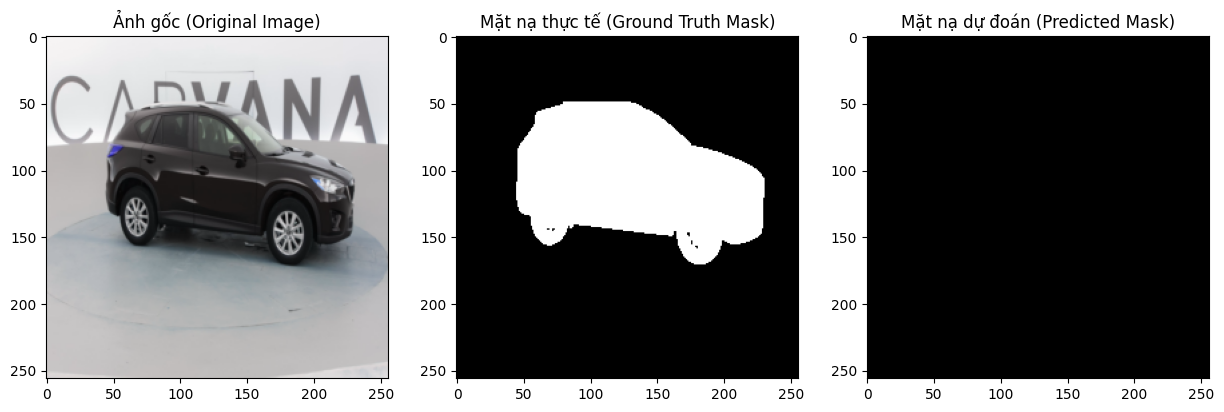

In [10]:
model.eval() 
with torch.no_grad(): 

    images, masks = next(iter(val_loader))
    test_image = images[0].unsqueeze(0).to(device) 
    test_mask = masks[0].squeeze().cpu().numpy()

    pred = model(test_image)
    pred_mask = pred.squeeze().cpu().numpy() 
    pred_mask = pred_mask > 0.5 

original_img = images[0].permute(1, 2, 0).cpu().numpy()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_img) 
plt.title("Ảnh gốc (Original Image)")

plt.subplot(1, 3, 2)
plt.imshow(test_mask, cmap="gray") 
plt.title("Mặt nạ thực tế (Ground Truth Mask)")

plt.subplot(1, 3, 3)
plt.imshow(pred_mask, cmap="gray") 
plt.title("Mặt nạ dự đoán (Predicted Mask)")

plt.show()

# bài 11: LR

In [11]:
import torch

lr_list = [0.01, 0.001, 0.0001] 

for lr in lr_list:
    print(f"\nLR: {lr} ")
    
    test_model = SimpleUNet().to(device)
    test_optimizer = torch.optim.Adam(test_model.parameters(), lr=lr) 
    criterion = torch.nn.BCELoss() 
    
    for epoch in range(4):
        test_model.train()
        epoch_loss = 0.0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            preds = test_model(images)
            loss = criterion(preds, masks)
            
            test_optimizer.zero_grad()
            loss.backward()
            test_optimizer.step()
            epoch_loss += loss.item()
            
        print(f"Epoch {epoch+1} - Loss: {epoch_loss/len(train_loader):.4f}")


LR: 0.01 
Epoch 1 - Loss: 0.0177
Epoch 2 - Loss: 0.0063
Epoch 3 - Loss: 0.0063
Epoch 4 - Loss: 0.0063

LR: 0.001 
Epoch 1 - Loss: 0.0538
Epoch 2 - Loss: 0.0071
Epoch 3 - Loss: 0.0064
Epoch 4 - Loss: 0.0064

LR: 0.0001 
Epoch 1 - Loss: 0.3096
Epoch 2 - Loss: 0.0140
Epoch 3 - Loss: 0.0109
Epoch 4 - Loss: 0.0103


# bài 12 batch

In [12]:
batch_sizes = [4, 8, 16] 

for bs in batch_sizes:
    print(f"\nKhởi tạo DataLoader với Batch Size = {bs}...") 
    
    temp_train_loader = DataLoader(
        train_dataset,
        batch_size=bs,
        shuffle=True
    )

    images, masks = next(iter(temp_train_loader))
    print(f"Kích thước tensor hình ảnh: {images.shape} (Batch size là {images.shape[0]})")


Khởi tạo DataLoader với Batch Size = 4...
Kích thước tensor hình ảnh: torch.Size([4, 3, 256, 256]) (Batch size là 4)

Khởi tạo DataLoader với Batch Size = 8...
Kích thước tensor hình ảnh: torch.Size([8, 3, 256, 256]) (Batch size là 8)

Khởi tạo DataLoader với Batch Size = 16...
Kích thước tensor hình ảnh: torch.Size([16, 3, 256, 256]) (Batch size là 16)


# bài 13 Phân tích dự đoán sai


Trường hợp sai thứ 1: Index 0 trên tập Validation với IoU = 1.0000


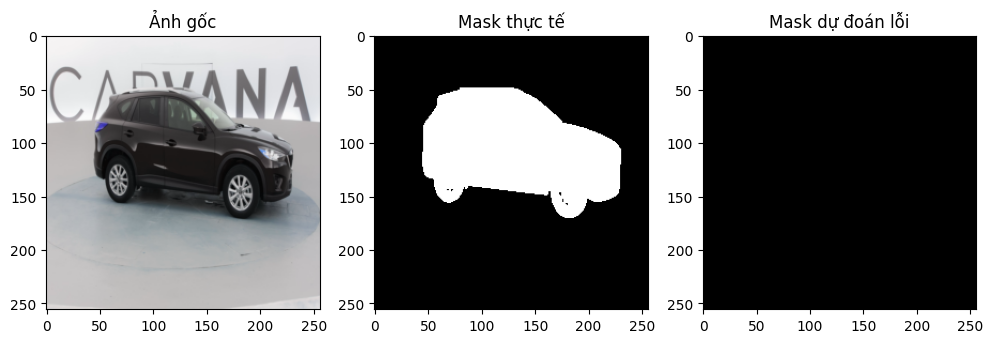


Trường hợp sai thứ 2: Index 1 trên tập Validation với IoU = 1.0000


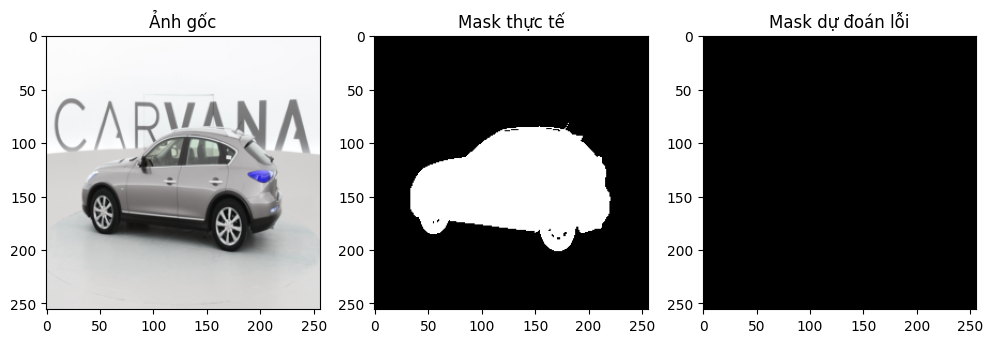

In [13]:
model.eval()
worst_cases = [] 

with torch.no_grad():
    for idx in range(len(val_dataset)):
        image, mask = val_dataset[idx]
        input_tensor = image.unsqueeze(0).to(device)
        
        pred = model(input_tensor)
        pred_np = (pred.squeeze().cpu().numpy() > 0.5).astype(bool)
        mask_np = (mask.squeeze().numpy() > 0.5).astype(bool)
        
        iou_score = compute_iou(pred_np, mask_np)
        worst_cases.append((idx, iou_score, image, mask, pred_np))

worst_cases.sort(key=lambda x: x[1])

for i in range(2):
    idx, score, img, msk, prd = worst_cases[i]
    print(f"\nTrường hợp sai thứ {i+1}: Index {idx} trên tập Validation với IoU = {score:.4f}")
    
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(img.permute(1, 2, 0).numpy())
    plt.title("Ảnh gốc")
    
    plt.subplot(1, 3, 2)
    plt.imshow(msk.squeeze().numpy(), cmap="gray")
    plt.title("Mask thực tế")
    
    plt.subplot(1, 3, 3)
    plt.imshow(prd, cmap="gray")
    plt.title("Mask dự đoán lỗi")
    plt.show()

# bài 14: Data Aug

In [14]:
augmented_image_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])
print("Đã cập nhật pipeline tiền xử lý bổ sung phương pháp tăng cường dữ liệu (Data Augmentation).") 

Đã cập nhật pipeline tiền xử lý bổ sung phương pháp tăng cường dữ liệu (Data Augmentation).


# bài 15: DeepLabv3 Segmentation

In [15]:
import torchvision.models.segmentation as segmentation_models


alternative_model = segmentation_models.deeplabv3_resnet50(num_classes=1) 

alternative_model = alternative_model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 207MB/s]
